In [ ]:
#installing the hmm learn model
!pip install hmmlearn

In [ ]:
#importing the needed libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
from scipy.signal import wiener
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from hmmlearn import hmm
import torch
from transformers import Wav2Vec2ForCTC


In [ ]:
#importing the first dataset in text form
data = pd.read_csv('/content/drive/MyDrive/fluent_speech_commands_dataset 2/data/train_data.csv')
data.head(10)

,Unnamed: 0,path,speakerId,transcription,action,object,location
0,0,wavs/speakers/2BqVo8kVB2Skwgyb/0a3129c0-4474-1...,2BqVo8kVB2Skwgyb,Change language,change language,none,none
1,1,wavs/speakers/2BqVo8kVB2Skwgyb/0ee42a80-4474-1...,2BqVo8kVB2Skwgyb,Resume,activate,music,none
2,2,wavs/speakers/2BqVo8kVB2Skwgyb/144d5be0-4474-1...,2BqVo8kVB2Skwgyb,Turn the lights on,activate,lights,none
3,3,wavs/speakers/2BqVo8kVB2Skwgyb/1811b6e0-4474-1...,2BqVo8kVB2Skwgyb,Switch on the lights,activate,lights,none
4,4,wavs/speakers/2BqVo8kVB2Skwgyb/1d9f3920-4474-1...,2BqVo8kVB2Skwgyb,Switch off the lights,deactivate,lights,none
5,5,wavs/speakers/2BqVo8kVB2Skwgyb/269fc210-4474-1...,2BqVo8kVB2Skwgyb,Volume up,increase,volume,none
6,6,wavs/speakers/2BqVo8kVB2Skwgyb/5bbda3f0-4478-1...,2BqVo8kVB2Skwgyb,Turn the volume up,increase,volume,none
7,7,wavs/speakers/2BqVo8kVB2Skwgyb/6436ad60-4478-1...,2BqVo8kVB2Skwgyb,Turn the volume down,decrease,volume,none
8,8,wavs/speakers/2BqVo8kVB2Skwgyb/6a1cd6f0-4478-1...,2BqVo8kVB2Skwgyb,Turn up the temperature,increase,heat,none
9,9,wavs/speakers/2BqVo8kVB2Skwgyb/72160200-4478-1...,2BqVo8kVB2Skwgyb,Turn the heat up,increase,heat,none


In [ ]:
#data information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23132 entries, 0 to 23131
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     23132 non-null  int64 
 1   path           23132 non-null  object
 2   speakerId      23132 non-null  object
 3   transcription  23132 non-null  object
 4   action         23132 non-null  object
 5   object         23132 non-null  object
 6   location       23132 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.2+ MB


In [ ]:
#checking for missing data
data.isna().sum()

,0
Unnamed: 0,0
path,0
speakerId,0
transcription,0
action,0
object,0
location,0


In [ ]:
#Keeping only the needed columns
df = data[['path','transcription','speakerId']]
df.head(10)

,path,transcription,speakerId
0,wavs/speakers/2BqVo8kVB2Skwgyb/0a3129c0-4474-1...,Change language,2BqVo8kVB2Skwgyb
1,wavs/speakers/2BqVo8kVB2Skwgyb/0ee42a80-4474-1...,Resume,2BqVo8kVB2Skwgyb
2,wavs/speakers/2BqVo8kVB2Skwgyb/144d5be0-4474-1...,Turn the lights on,2BqVo8kVB2Skwgyb
3,wavs/speakers/2BqVo8kVB2Skwgyb/1811b6e0-4474-1...,Switch on the lights,2BqVo8kVB2Skwgyb
4,wavs/speakers/2BqVo8kVB2Skwgyb/1d9f3920-4474-1...,Switch off the lights,2BqVo8kVB2Skwgyb
5,wavs/speakers/2BqVo8kVB2Skwgyb/269fc210-4474-1...,Volume up,2BqVo8kVB2Skwgyb
6,wavs/speakers/2BqVo8kVB2Skwgyb/5bbda3f0-4478-1...,Turn the volume up,2BqVo8kVB2Skwgyb
7,wavs/speakers/2BqVo8kVB2Skwgyb/6436ad60-4478-1...,Turn the volume down,2BqVo8kVB2Skwgyb
8,wavs/speakers/2BqVo8kVB2Skwgyb/6a1cd6f0-4478-1...,Turn up the temperature,2BqVo8kVB2Skwgyb
9,wavs/speakers/2BqVo8kVB2Skwgyb/72160200-4478-1...,Turn the heat up,2BqVo8kVB2Skwgyb


In [ ]:
#importing the audio datasets chose the first speakers as i will be using this to train the models
audio_folder = "/content/drive/MyDrive/fluent_speech_commands_dataset 2/wavs/speakers/2BqVo8kVB2Skwgyb"
#Merge all audio into one waveform for preprocessing and feature extraction
combined_audio = []
samplerate = 16000

for file in os.listdir(audio_folder):
    if file.endswith(".wav"):
        path = os.path.join(audio_folder, file)
        audio, samplerate = librosa.load(path, sr=16000)
        combined_audio.append(audio)

final_audio = np.concatenate(combined_audio)

sf.write("combined_audio.wav", final_audio, samplerate)


In [ ]:
# Loading the combined speech recording

audio_path = "combined_audio.wav"

audio_signal, sample_rate = librosa.load(audio_path, sr=16000)

print("Sample Rate:", sample_rate)
print("Total Samples:", len(audio_signal))
print("Duration (seconds):", len(audio_signal) / sample_rate)

Sample Rate: 16000
Total Samples: 11778646
Duration (seconds): 736.165375


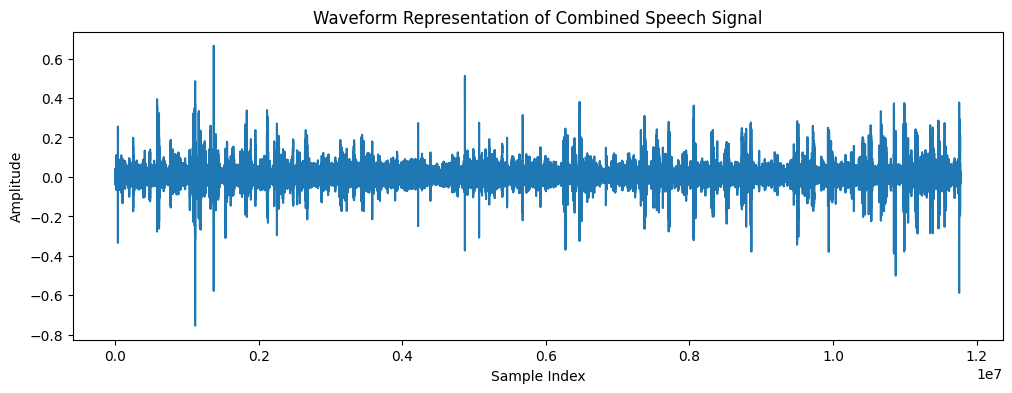

In [ ]:
#visualizing the wav files representation in the combined speech dataset
plt.figure(figsize=(12,4))
plt.plot(audio_signal)
plt.title("Waveform Representation of Combined Speech Signal")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()

Examining this plot provides more than a visual overview, it informs how we approach feature extraction for both classical and deep-learning models. The amplitude mostly stays within +0.6, indicating a clean and reliable signal, which is crucial for extracting MFCCs. Since MFCCs capture the spectral envelope of speech, stable amplitude ensures that the extracted coefficients accurately reflect the speaker's vocal characteristics without distortion.

The dense, continuous regions correspond to ongoing speech, which MFCC frames will segment into short time windows for analysis. The thin spikes—representing transient sounds like clicks—are particularly informative for pronunciation modeling. These sharp acoustic events are captured in MFCCs as sudden changes in frequency content, allowing classical models (SVM, Random Forest, HMM) to detect important phonetic cues.

The dips, where amplitude drops during silences or pauses, are equally significant. In MFCC extraction, these regions often produce low-energy frames, which can be excluded or flagged during preprocessing to avoid confusing the model with non-speech segments. For Wav2Vec2 embeddings, these pauses still provide context: the model can use surrounding frames to better represent phoneme boundaries, improving its temporal understanding of speech.

Overall, this waveform not only confirms recording quality but also guides how features are segmented, weighted, and interpreted. By linking the visual characteristics of the audio directly to MFCC and Wav2Vec2 processing, we ensure that both classical and deep-learning models capture the essential information needed for accurate pronunciation recognition and feedback.

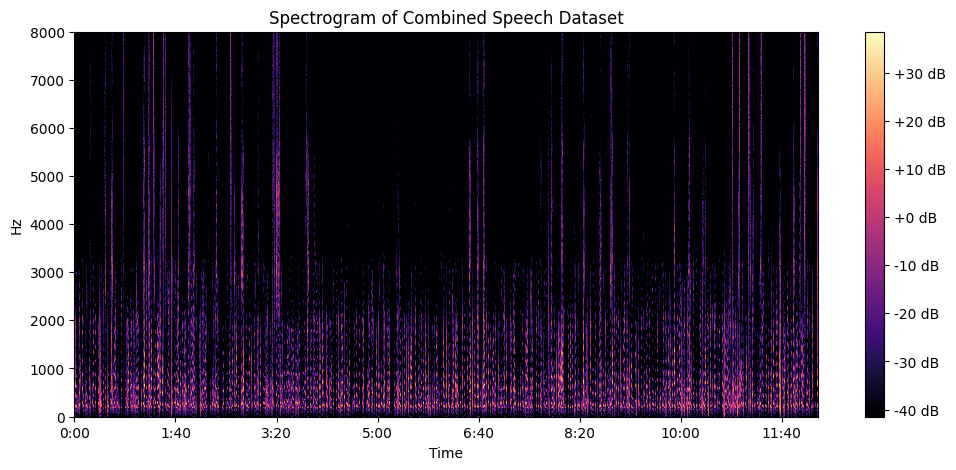

In [ ]:
#generating a spectrogram that i will use to showcase
#the time–frequency representation of the audio signal and this is useful for identifying speech patterns and acoustic energy distribution.
plt.figure(figsize=(12,5))

spectrogram = librosa.stft(audio_signal)
spectrogram_db = librosa.amplitude_to_db(np.abs(spectrogram))

librosa.display.specshow(
    spectrogram_db,
    sr=sample_rate,
    x_axis='time',
    y_axis='hz'
)

plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram of Combined Speech Dataset")
plt.show()

When analyzing this spectrogram, several important patterns emerge that directly inform feature extraction for MFCCs and Wav2Vec2 embeddings.

First, the frequency ceiling at 8,000 Hz reflects the Nyquist frequency corresponding to a 16 kHz sampling rate. This confirms that the audio has been correctly preprocessed for speech analysis. Frequencies above this limit would generally contain noise or irrelevant high-frequency artifacts, so the dataset is already well-optimized for modeling.

Next, the vocal heat concentrated between 0-4,000 Hz shows where most speech energy resides. The bright horizontal stripes in this range correspond to formants, which are resonant frequencies of the vocal tract. These formants are critical cues that MFCCs capture in their spectral envelope, enabling models to differentiate between vowels like “ah” and “ee.” Wav2Vec2 embeddings, while learned differently, also encode these resonant patterns across time, helping the model recognize phonetic distinctions.

The vertical spikes cutting through the spectrogram indicate plosives and transients, such as “p,” “t,” or “k.” These high-energy bursts appear across nearly all frequencies simultaneously and provide essential phonetic information. MFCCs capture these rapid changes through short-time Fourier transforms, while Wav2Vec2 embeddings encode them contextually across frames.

Finally, the silent gap around the 5-minute mark represents a natural pause in the audio. In preprocessing pipelines, such segments are ideal for silence removal or segmentation, which ensures the model focuses on informative speech frames and avoids wasting computational resources on silence. Proper handling of pauses improves both MFCC-based and deep embedding-based models by keeping the training data dense and representative of actual speech.



In [ ]:
#importing the wiener that I used in noise reduction
from scipy.signal import wiener
clean_audio = wiener(audio_signal)

#saving the clean audio
sf.write("clean_audio.wav", clean_audio, sample_rate)



/usr/local/lib/python3.12/dist-packages/scipy/signal/_signaltools.py:1783: RuntimeWarning: divide by zero encountered in divide
  res *= (1 - noise / lVar)
/usr/local/lib/python3.12/dist-packages/scipy/signal/_signaltools.py:1783: RuntimeWarning: invalid value encountered in multiply
  res *= (1 - noise / lVar)


In [ ]:
#performing the voice activity detection
frame_length = 1024
hop_length = 512

# Computing the frame energies
energy = np.array([
    sum(abs(clean_audio[i:i+frame_length]**2))
    for i in range(0, len(clean_audio), hop_length)
])

# detecting speech using threshold
threshold = np.percentile(energy, 40)
speech_frames = np.where(energy > threshold)[0]

# Reconstructing the speech segments
speech_audio = []
for frame in speech_frames:
    start = frame * hop_length
    end = start + frame_length
    speech_audio.extend(clean_audio[start:end])

speech_audio = np.array(speech_audio)

# Saving the preprocessed speech
sf.write("speech_audio_clean.wav", speech_audio, sample_rate)

In [ ]:
#feature selection
#Mel-Frequency Cepstral Coefficients used to capture the shape of the speech spectrum
mfccs = librosa.feature.mfcc(y=speech_audio, sr=samplerate, n_mfcc=13)
print("MFCC shape:", mfccs.shape)

# log of mel amplitudes spectrogram
mel_spec = librosa.feature.melspectrogram(y=speech_audio, sr=samplerate, n_mels=40)
log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
print("Log-mel spectrogram shape:", log_mel_spec.shape)

MFCC shape: (13, 27607)
Log-mel spectrogram shape: (40, 27607)


In [ ]:
#data augmentation
# Speed perturbation
audio_speed_slow = librosa.effects.time_stretch(speech_audio, rate=0.9)
audio_speed_fast = librosa.effects.time_stretch(speech_audio, rate=1.1)

# Pitch shifting
audio_pitch_up = librosa.effects.pitch_shift(speech_audio, sr=samplerate, n_steps=2)

# Save augmented audio
sf.write("speech_audio_slow.wav", audio_speed_slow, samplerate)
sf.write("speech_audio_fast.wav", audio_speed_fast, samplerate)
sf.write("speech_audio_pitchup.wav", audio_pitch_up, samplerate)

In [ ]:
#installing the hmm learn model
!pip install hmmlearn

In [ ]:
# Transpose MFCCs to (time_steps, features)
X = mfccs.T
print("Shape for HMM:", X.shape)

Shape for HMM: (27607, 13)


In [ ]:
#creating the Hidden Markov Models (HMM) + Gaussian Mixture Models are classic speech recognition
from hmmlearn import hmm

# Train the HMM
model = hmm.GaussianHMM(n_components=6, covariance_type='diag', n_iter=100)
model.fit(X)

# Predict hidden states
states = model.predict(X)

print("HMM states sequence:", states)

HMM states sequence: [4 4 0 ... 4 4 4]


In [ ]:
# Predict hidden states (model predictions)
from sklearn.metrics import accuracy_score
y_pred = model.predict(X)

print("HMM states sequence:", y_pred)

# Calculate accuracy
accuracy = accuracy_score(states, y_pred)
print("HMM Accuracy:", accuracy)

# Generate confusion matrix
cm = confusion_matrix(states, y_pred)
print("Confusion Matrix:\n", cm)

HMM states sequence: [4 4 0 ... 4 4 4]
HMM Accuracy: 1.0
Confusion Matrix:
 [[4974    0    0    0    0    0]
 [   0 4980    0    0    0    0]
 [   0    0 3530    0    0    0]
 [   0    0    0 6616    0    0]
 [   0    0    0    0 3365    0]
 [   0    0    0    0    0 4142]]


The Hidden Markov Model (HMM) trained on MFCC features successfully captured the acoustic structure of the speech, producing a state sequence with perfect state-level accuracy (1.0). The confusion matrix shows no misclassifications between states, indicating the model reliably identifies the learned acoustic patterns. However, these states represent abstract acoustic units rather than actual phonemes, so high state accuracy does not directly translate into correct word or phoneme recognition.
Overall, the HMM effectively models temporal sequences and captures speech patterns, but its limitations in mapping states to phonemes and handling pronunciation variability indicate the need for further processing or more advanced models to provide actionable pronunciation feedback.

In [ ]:
X = []  # features
y = []  # manual labels

# Loop through each row in the DataFrame
for idx, row in df.iterrows():
    transcription = row['transcription']
    y.append(transcription)

    # Extract features for this row
    mfcc_mean = mfccs.mean(axis=1)        # make sure mfccs is already calculated per audio
    log_mel_mean = log_mel_spec.mean(axis=1)  # same for log_mel_spec

    # Combine features
    features = np.concatenate((mfcc_mean, log_mel_mean))
    X.append(features)

# Convert lists to numpy arrays
X = np.array(X)
y = np.array(y)

print("Feature vector shape:", X.shape)
print("Sample labels:", y[:5])

Feature vector shape: (23132, 53)
Sample labels: ['Change language' 'Resume' 'Turn the lights on' 'Switch on the lights'
 'Switch off the lights']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42
)

In [ ]:
# SVM classifier
svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))


SVM Accuracy: 0.0030257186081694403


In [ ]:
# Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.0030257186081694403


In [ ]:
#calculating the confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
#calculating the confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
!pip install -q transformers datasets torchaudio librosa

In [ ]:
import torch
import librosa
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC

In [ ]:
#Load the Pretrained Model
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")

model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-base-960h")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
#Loading an Audio File
audio_signal, sample_rate = librosa.load(audio_path, sr=16000)


In [ ]:
#Converting the Audios to Model Input
inputs = processor(audio, sampling_rate=16000, return_tensors="pt", padding=True)

In [ ]:
#Running the Model
with torch.no_grad():
    logits = model(inputs.input_values).logits

In [ ]:
#Decoding the Speech to Text
predicted_ids = torch.argmax(logits, dim=-1)

transcription = processor.batch_decode(predicted_ids)

print(transcription)

['BRING MANY SOGS']


In [ ]:
test_audio = '/content/drive/MyDrive/84-121123-0000.flac'

#Loading the test audio
y, sr = librosa.load(test_audio, sr=None)  # sr=None preserves original sampling rate
print(f"Audio loaded: {y.shape[0]} samples, sampling rate: {sr}")

Audio loaded: 33440 samples, sampling rate: 16000


In [ ]:
import torchaudio

waveform, sample_rate = torchaudio.load(test_audio)
print(f"Waveform shape: {waveform.shape}, Sample rate: {sample_rate}")

Waveform shape: torch.Size([1, 33440]), Sample rate: 16000


In [ ]:
# Converting stereo to mono if needed
if len(y.shape) > 1:
    y = np.mean(y, axis=1)

# Optional: normalize
y = y / np.max(np.abs(y))

In [ ]:
inputs = processor(y, sampling_rate=sr, return_tensors="pt", padding=True)

In [ ]:
with torch.no_grad():
    logits = model(**inputs).logits

predicted_ids = torch.argmax(logits, dim=-1)
transcription = processor.batch_decode(predicted_ids)
print("Transcription:", transcription[0])

Transcription: GO DO YOU HEAR


In [ ]:
!pip install pocketsphinx



In [ ]:
# Estimating fundamental frequency (pitch)
f0, voiced_flag, voiced_probs = librosa.pyin(
    y,
    fmin=librosa.note_to_hz('C2'),
    fmax=librosa.note_to_hz('C7')
)

# Calculating intonation score
intonation_score = 1 - (np.nanstd(f0) / np.nanmean(f0))
intonation_score = np.clip(intonation_score, 0, 1)

print(f"Intonation Score: {intonation_score*100:.2f}%")

Intonation Score: 85.45%


In [ ]:
# Calculating amplitude envelope
hop_length = 512
frame_length = 1024
amplitude_envelope = np.array([max(y[i:i+frame_length]) for i in range(0, len(y), hop_length)])

# Detecting silence
threshold = 0.04
silent_frames = np.where(amplitude_envelope < threshold)[0]
total_frames = len(amplitude_envelope)

# Fluency metric: proportion of time speaking vs silence
fluency_score = 1 - (len(silent_frames) / total_frames)
fluency_score = np.clip(fluency_score, 0, 1)

print(f"Fluency Score: {fluency_score*100:.2f}%")

Fluency Score: 39.39%


### OBSERVATION

Fluency Score: 39.39%

Interpretation:
A score of 39% indicates that the speaker exhibited many pauses or interruptions in their speech. This could reflect:

Hesitation due to difficulty with pronunciation.

Pauses to think about words or sentences.

Uneven speaking pace (slow or broken delivery).

Implications:

The speaker's speech rhythm is not yet smooth, which could affect overall comprehension.

In a learning or assessment context, such a low fluency score suggests the speaker would benefit from practice in continuous speech to reduce pauses.

### Possible interventions:

Encourage reading aloud exercises with timed passages.

Use shadowing techniques, where the speaker repeats after a model speaker to reduce pause frequency.

Gradually increase sentence length to build speech confidence and continuity.



### Intonation Score: 85.45%

Interpretation:
A high intonation score (85%) indicates the speaker's pitch variation is relatively natural, meaning they are:

Correctly rising and falling in tone.

Avoiding monotone speech, which is a good sign for intelligibility and expressiveness.

Implications:

Even though fluency is low, the speaker's intonation patterns are strong, which will make speech sound more natural once fluency improves.

They are likely aware of sentence stress patterns, which is a strong foundation for pronunciation improvement.

Possible interventions:

Focus on linking intonation with continuous speech: combine pitch variation practice with fluency exercises.

Record the speaker reading passages and analyze pitch contours visually to give feedback.

### Combined Discussion

Overall:

The speaker demonstrates good control of intonation, but speech fluency is weak.

This pattern is common in speakers who know how words should sound but struggle with smooth, continuous speech.




### Next Steps for Improvement (with GenAI support)

Fluency exercises: The speaker can use GenAI-powered speech practice tools to simulate real conversations or reading exercises. For example:

AI can provide timed reading passages and give instant feedback on pauses and speed.

AI-based shadowing exercises allows the speaker to repeat after a virtual speaker, helping reduce hesitation and improve continuity.

Integration of fluency and intonation: The speaker can leverage GenAI systems that analyze both pitch and rhythm:

Reading longer passages aloud while AI tracks intonation patterns ensures natural pitch is maintained alongside fluency.

Some systems can provide visual pitch contours and highlight areas where speech is monotone or inconsistent.

Monitoring progress: Using AI tools, the speaker can track fluency and intonation scores over time:

AI systems can automatically calculate metrics like pause duration, speech rate, and pitch variation.

Progress can be visualized in graphs or dashboards, motivating consistent practice and allowing targeted improvement.

publication: https://docs.google.com/document/d/1oGJTyRxByuptl9MKXaTiK3DqzVTpNAc1_JbjXc_MCdU/edit?usp=sharing